In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("buithanhxuan/vinbigdata-yolo-dataset-with-wbf-3x-downscaled")

print("Path to dataset files:", path)

In [ ]:
import os

dataset_path = "/kaggle/input/datasets/buithanhxuan/vinbigdata-yolo-dataset-with-wbf-3x-downscaled"
print(os.listdir(dataset_path))

In [ ]:
import os

base = "/kaggle/input/datasets/buithanhxuan/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/vinbigdata-yolo-dataset-with-wbf-3x-downscaled"

for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # affiche les fichiers seulement 2 niveaux profonds
        for f in files[:3]:  # 3 premiers fichiers par dossier
            print(f"  {indent}{f}")
        if len(files) > 3:
            print(f"  {indent}... ({len(files)} fichiers total)")

In [ ]:
yaml_path = "/kaggle/input/datasets/buithanhxuan/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/data.yaml"

with open(yaml_path, 'r') as f:
    print(f.read())

In [ ]:
import os

base = "/kaggle/input/datasets/buithanhxuan/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/vinbigdata-yolo-dataset-with-wbf-3x-downscaled"

# Compter les images Cardiomegaly (classe 3) dans train et val
for split in ['train', 'val']:
    labels_path = f"{base}/{split}/labels"
    
    total_images = 0
    cardio_images = 0
    cardio_instances = 0
    
    for label_file in os.listdir(labels_path):
        total_images += 1
        with open(f"{labels_path}/{label_file}", 'r') as f:
            lines = f.readlines()
            for line in lines:
                if line.strip() and int(line.split()[0]) == 3:  # classe 3 = Cardiomegaly
                    cardio_instances += 1
                    cardio_images += 1
                    break  # une seule fois par image
    
    print(f"\n{split.upper()} :")
    print(f"  Total images     : {total_images}")
    print(f"  Images Cardiomegaly : {cardio_images}")
    print(f"  Instances totales   : {cardio_instances}")
    print(f"  Pourcentage      : {cardio_images/total_images*100:.1f}%")

In [ ]:
import yaml

config = {
    'path': '/kaggle/input/datasets/buithanhxuan/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/vinbigdata-yolo-dataset-with-wbf-3x-downscaled',
    'train': 'train/images',
    'val': 'val/images',
    'nc': 15,
    'names': [                  
        'Aortic_enlargement',
        'Atelectasis', 
        'Calcification', 
        'Cardiomegaly',         # ← index 3
        'Consolidation', 
        'ILD', 
        'Infiltration', 
        'Lung_Opacity', 
        'Nodule/Mass', 
        'Other_lesion', 
        'Pleural_effusion', 
        'Pleural_thickening', 
        'Pneumothorax', 
        'Pulmonary_fibrosis', 
        'No finding'
    ]
}

yaml_path = '/kaggle/working/vinbig.yaml'  # ← nouveau nom pour ne pas écraser l'ancien
with open(yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print("✅ vinbig.yaml créé !")
with open(yaml_path, 'r') as f:
    print(f.read())

In [3]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='/kaggle/working/vinbig.yaml',
    epochs=50,
    imgsz=512,
    batch=16,
    device=0,
    project='/kaggle/working/runs',
    name='yolov8n_vinbig_cardio',
    exist_ok=True,
    classes=[3],        
    verbose=True
)


print("\n✅ Entraînement terminé !")

In [3]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data='/kaggle/working/vinbig.yaml',
    epochs=100,
    imgsz=512,
    batch=16,
    device=0,
    project='/kaggle/working/runs',
    name='yolov8s_vinbig_v2',
    exist_ok=True,
    classes=[3],  
   
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.4,
    fliplr=0.5,
    flipud=0.0,
    degrees=10,
    translate=0.1,

    patience=20,        # stop early if no improvement
    optimizer='AdamW',
    lr0=0.001,
    weight_decay=0.0005,
    verbose=True
)

print("Training done!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/vinbig.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=512

In [4]:
from ultralytics import YOLO
import shutil

model = YOLO('yolov8s.pt')

results = model.train(
    data='/kaggle/working/vinbig.yaml',
    epochs=100,
    imgsz=512,
    batch=16,
    device=0,
    project='/kaggle/working/runs',
    name='yolov8s_vinbig_cardio',
    exist_ok=True,
    classes=[3],      
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.4,
    fliplr=0.5,
    flipud=0.0,
    degrees=10,
    translate=0.1,
    patience=20,
    optimizer='AdamW',
    lr0=0.001,
    weight_decay=0.0005,
    verbose=True
)

shutil.copy(
    '/kaggle/working/runs/yolov8s_vinbig_cardio/weights/best.pt',
    '/kaggle/working/best_cardio_v3.pt'
)
print("✅ v3 sauvegardé !")
print("Training done!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=[3], close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/vinbig.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=512,

In [27]:
import shutil

shutil.copy(
    '/kaggle/working/runs/yolov8s_vinbig_v2/weights/best.pt',
    '/kaggle/working/best_cardio_v2.pt'
)
print("✅ Modèle sauvegardé !")

✅ Modèle sauvegardé !



0: 512x512 1 No finding, 8.3ms
1: 512x512 1 Aortic_enlargement, 1 Cardiomegaly, 1 No finding, 8.3ms
2: 512x512 1 Aortic_enlargement, 1 Nodule/Mass, 8.3ms
3: 512x512 1 No finding, 8.3ms
4: 512x512 1 Aortic_enlargement, 1 Cardiomegaly, 8.3ms
5: 512x512 1 No finding, 8.3ms
Speed: 2.1ms preprocess, 8.3ms inference, 0.8ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /kaggle/working/predictions/val_sample


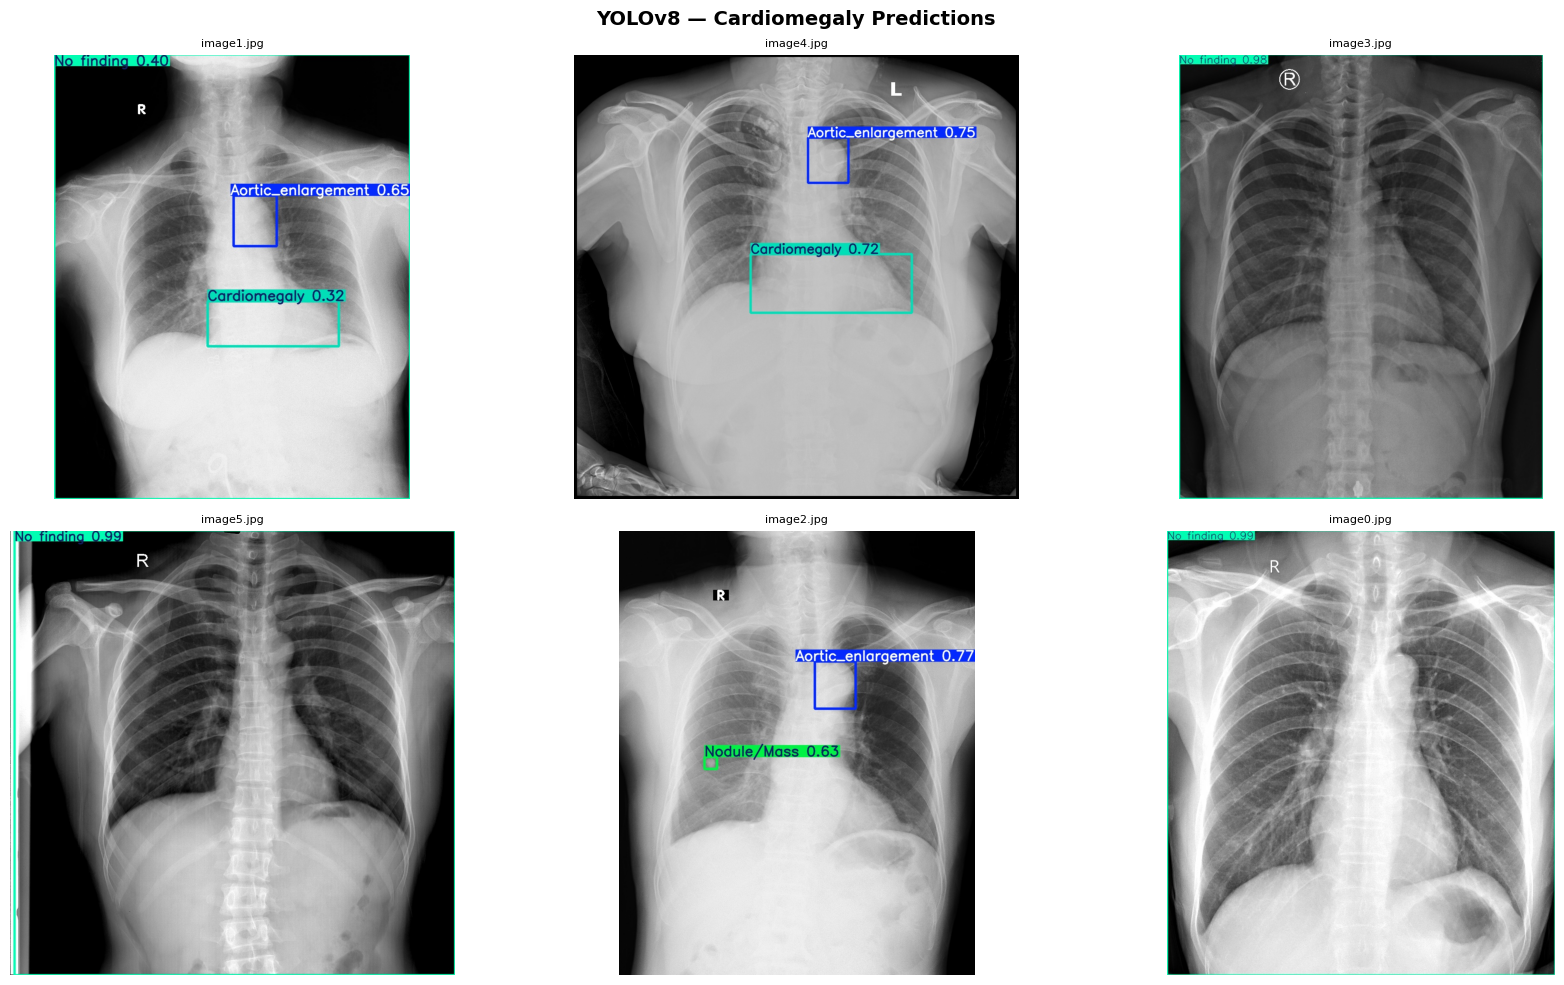

✅ Visualisation sauvegardée !


In [28]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Charger le meilleur modèle
model = YOLO('/kaggle/working/runs/yolov8s_vinbig_v2/weights/best.pt')

# Prendre 6 images du val set
val_images_path = "/kaggle/input/datasets/buithanhxuan/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/val/images"
images = os.listdir(val_images_path)[:6]

# Lancer les prédictions
results = model.predict(
    source=[f"{val_images_path}/{img}" for img in images],
    conf=0.3,       # seuil de confiance
    save=True,
    project='/kaggle/working/predictions',
    name='val_sample',
    exist_ok=True
)

# Afficher les résultats
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

pred_folder = '/kaggle/working/predictions/val_sample'
pred_images = os.listdir(pred_folder)[:6]

for i, img_name in enumerate(pred_images):
    img = mpimg.imread(f"{pred_folder}/{img_name}")
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(img_name, fontsize=8)

plt.suptitle('YOLOv8 — Cardiomegaly Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/yolov8_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualisation sauvegardée !")

In [29]:
import os

# Vérifier si le modèle est encore là
path = '/kaggle/working/runs/yolov8s_vinbig_v2/weights/best.pt'
if os.path.exists(path):
    print("✅ Modèle encore présent !")
else:
    print("❌ Modèle perdu — session expirée")
    # Lister ce qui reste dans /kaggle/working
    print(os.listdir('/kaggle/working'))

✅ Modèle encore présent !


In [30]:
import os
import random

val_images_path = "/kaggle/input/datasets/buithanhxuan/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/val/images"
val_labels_path = "/kaggle/input/datasets/buithanhxuan/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/val/labels"

# Trouver les images SANS Cardiomegaly (classe 3)
normal_images = []

for label_file in os.listdir(val_labels_path):
    with open(f"{val_labels_path}/{label_file}", 'r') as f:
        lines = f.readlines()
    
    has_cardio = any(int(l.split()[0]) == 3 for l in lines if l.strip())
    
    if not has_cardio:
        img_name = label_file.replace('.txt', '.jpg')
        img_path = f"{val_images_path}/{img_name}"
        if os.path.exists(img_path):
            normal_images.append(img_path)

print(f"Images sans Cardiomegaly : {len(normal_images)}")

# Prendre 6 aléatoires
sample = random.sample(normal_images, 6)
print("✅ Sample prêt !")

Images sans Cardiomegaly : 2553
✅ Sample prêt !



0: 512x512 1 No finding, 8.0ms
1: 512x512 1 No finding, 8.0ms
2: 512x512 1 No finding, 8.0ms
3: 512x512 1 No finding, 8.0ms
4: 512x512 1 No finding, 8.0ms
5: 512x512 1 No finding, 8.0ms
Speed: 2.5ms preprocess, 8.0ms inference, 0.8ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /kaggle/working/predictions/normal_test

=== Résultats ===
❌ Image 1 : 1 fausse(s) alarme(s) !
❌ Image 2 : 1 fausse(s) alarme(s) !
❌ Image 3 : 1 fausse(s) alarme(s) !
❌ Image 4 : 1 fausse(s) alarme(s) !
❌ Image 5 : 1 fausse(s) alarme(s) !
❌ Image 6 : 1 fausse(s) alarme(s) !

Fausses alarmes : 6/6


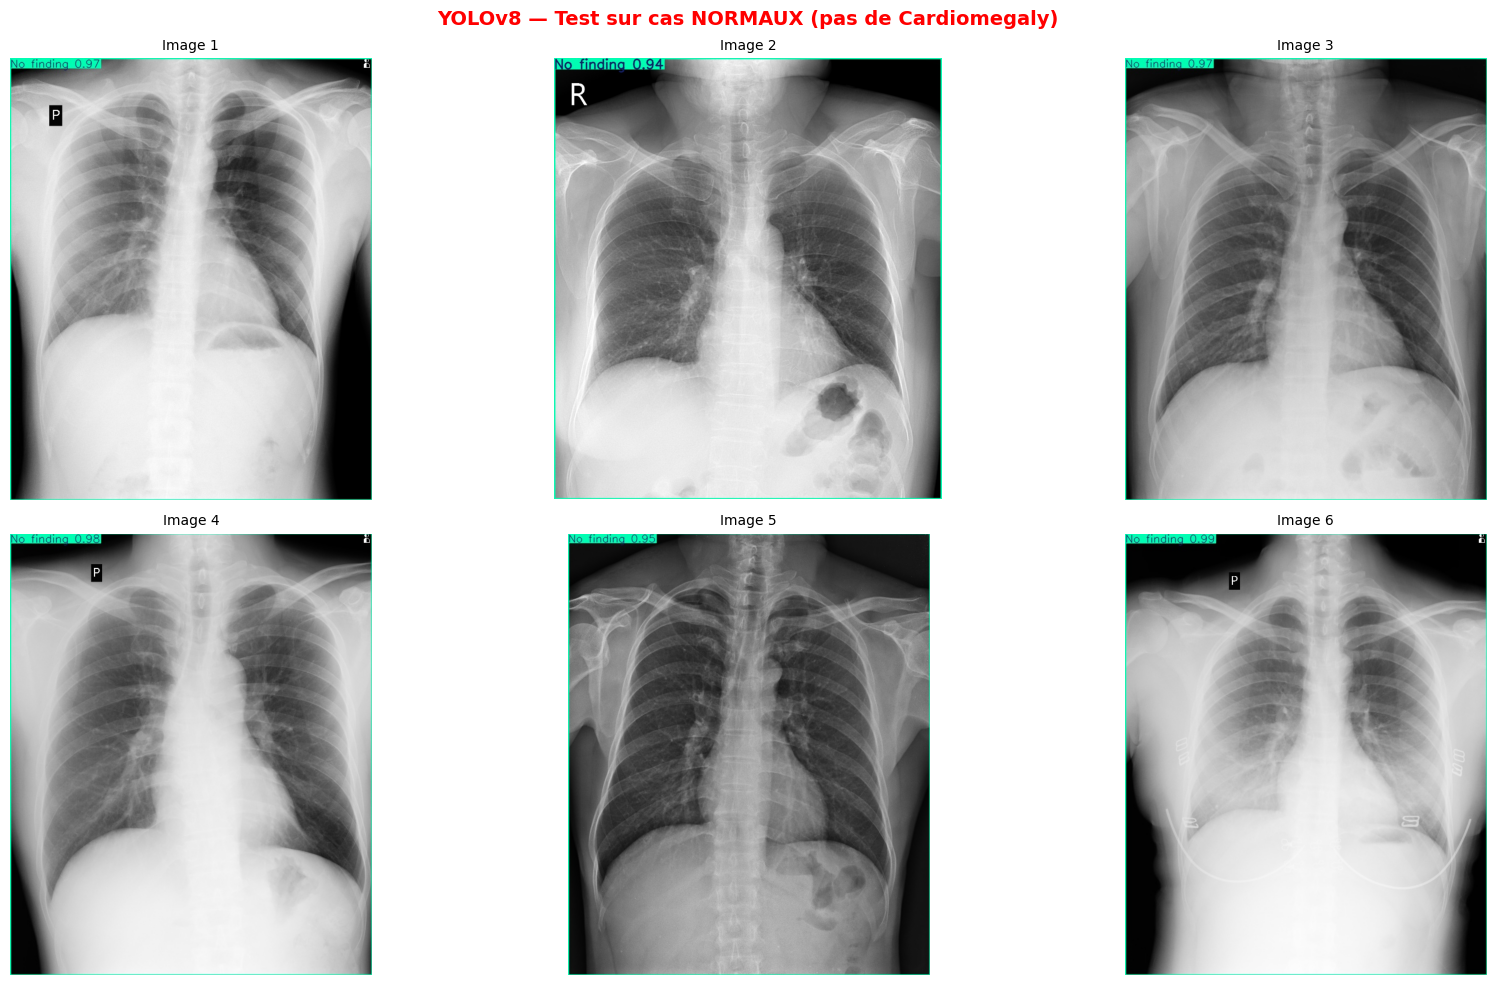

In [31]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

model = YOLO('/kaggle/working/best_cardio_v2.pt')

# Prédictions sur les 6 images normales
results = model.predict(
    source=sample,
    conf=0.3,
    save=True,
    project='/kaggle/working/predictions',
    name='normal_test',
    exist_ok=True
)

# Compter les fausses alarmes
print("\n=== Résultats ===")
false_alarms = 0
for i, r in enumerate(results):
    n_detections = len(r.boxes)
    if n_detections > 0:
        false_alarms += 1
        print(f"❌ Image {i+1} : {n_detections} fausse(s) alarme(s) !")
    else:
        print(f"✅ Image {i+1} : aucune détection — correct !")

print(f"\nFausses alarmes : {false_alarms}/6")

# Visualiser
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

pred_folder = '/kaggle/working/predictions/normal_test'
pred_images = sorted(os.listdir(pred_folder))[:6]

for i, img_name in enumerate(pred_images):
    img = mpimg.imread(f"{pred_folder}/{img_name}")
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Image {i+1}", fontsize=10)

plt.suptitle('YOLOv8 — Test sur cas NORMAUX (pas de Cardiomegaly)', 
             fontsize=14, fontweight='bold', color='red')
plt.tight_layout()
plt.savefig('/kaggle/working/normal_test.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
import random

# Tester sur 50 images normales cette fois
sample_large = random.sample(normal_images, 50)

results = model.predict(
    source=sample_large,
    conf=0.3,
    verbose=False
)

false_alarms = sum(1 for r in results if len(r.boxes) > 0)
correct = 50 - false_alarms

print(f"=== Test sur 50 cas normaux ===")
print(f"✅ Corrects (pas de détection) : {correct}/50")
print(f"❌ Fausses alarmes            : {false_alarms}/50")
print(f"Taux de fausses alarmes       : {false_alarms/50*100:.1f}%")

=== Test sur 50 cas normaux ===
✅ Corrects (pas de détection) : 0/50
❌ Fausses alarmes            : 50/50
Taux de fausses alarmes       : 100.0%


In [22]:
import os
print(os.path.exists('/kaggle/working/best_cardio.pt'))

True


In [23]:
import os
print(os.path.exists('/kaggle/input/datasets/jihaneelkh/test-images'))

True


Images trouvées : 6

0: 512x512 1 Aortic_enlargement, 1 Cardiomegaly, 8.1ms
1: 512x512 1 Cardiomegaly, 8.1ms
2: 512x512 (no detections), 8.1ms
3: 512x512 1 No finding, 8.1ms
4: 512x512 1 Lung_Opacity, 8.1ms
5: 512x512 1 Pneumothorax, 8.1ms
Speed: 1.8ms preprocess, 8.1ms inference, 0.7ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /kaggle/working/predictions/external_test

=== Résultats ===
🔴 x-ray-of-chest-of-patient-with-cardiomegaly.jpg → CARDIOMEGALY détecté (conf=0.77)
🔴 b8abe6f1628931f37515588a9d4b52.jpg → CARDIOMEGALY détecté (conf=0.70)
🟢 diagnostics-13-00599-g010.jpg → Rien détecté
🔴 461ed520cee63730b10662ed0a83e589.jpg → CARDIOMEGALY détecté (conf=0.95)
🔴 adff9b8bb2c498c4c00d161901b98341a06de78b0509b9a45fef8522939f6761_big_gallery.png → CARDIOMEGALY détecté (conf=0.36)
🔴 image001b01b5775-9e04-498f-83df-5724422a23f6.jpg → CARDIOMEGALY détecté (conf=0.44)


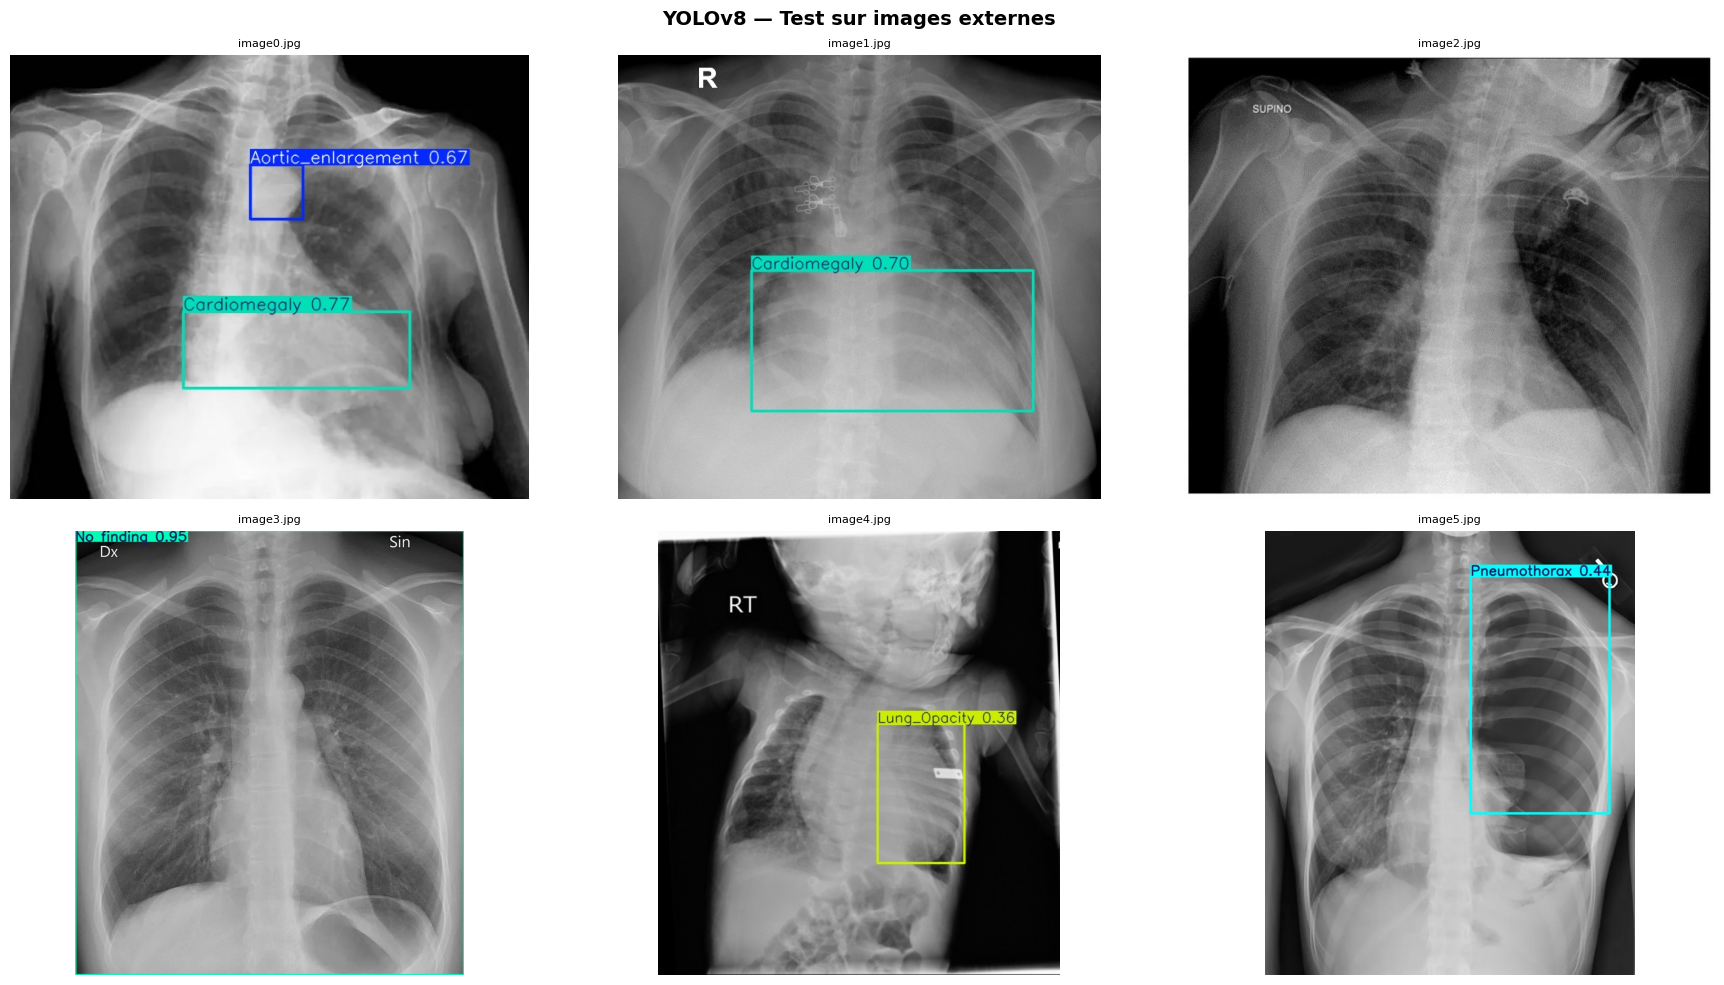

✅ Done !


In [32]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

model = YOLO('/kaggle/working/best_cardio_v2.pt')

images_path = '/kaggle/input/datasets/jihaneelkh/test-images'
images = [f"{images_path}/{f}" for f in os.listdir(images_path) 
          if f.endswith(('.jpg', '.png', '.jpeg'))]

print(f"Images trouvées : {len(images)}")

results = model.predict(
    source=images,
    conf=0.3,
    save=True,
    project='/kaggle/working/predictions',
    name='external_test',
    exist_ok=True
)

# Résultats
print("\n=== Résultats ===")
for i, (r, img_path) in enumerate(zip(results, images)):
    img_name = os.path.basename(img_path)
    if len(r.boxes) > 0:
        conf = r.boxes.conf[0].item()
        print(f"🔴 {img_name} → CARDIOMEGALY détecté (conf={conf:.2f})")
    else:
        print(f"🟢 {img_name} → Rien détecté")

# Visualisation
n = len(images)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

pred_folder = '/kaggle/working/predictions/external_test'
pred_images = sorted(os.listdir(pred_folder))

for i, img_name in enumerate(pred_images[:6]):
    img = mpimg.imread(f"{pred_folder}/{img_name}")
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(img_name[:30], fontsize=8)

plt.suptitle('YOLOv8 — Test sur images externes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/external_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Done !")

In [25]:
results = model.predict(
    source=['/kaggle/input/datasets/jihaneelkh/test-images/adff9b8bb2c498c4c00d161901b98341a06de78b0509b9a45fef8522939f6761_big_gallery.png'],
    conf=0.1,  
    save=False
)

for r in results:
    if len(r.boxes) > 0:
        for box in r.boxes:
            print(f"Détection : conf={box.conf[0]:.3f}")
    else:
        print("Aucune détection même à conf=0.1")


0: 512x480 1 Cardiomegaly, 1 Lung_Opacity, 2 Other_lesions, 1 Pleural_effusion, 1 Pleural_thickening, 42.3ms
Speed: 2.4ms preprocess, 42.3ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 480)
Détection : conf=0.373
Détection : conf=0.321
Détection : conf=0.159
Détection : conf=0.136
Détection : conf=0.118
Détection : conf=0.103


In [26]:
from ultralytics import YOLO

model = YOLO('/kaggle/working/best_cardio.pt')

# Vérifier sur quel dataset il a été entraîné
print(f"Classes : {model.names}")
print(f"Nombre de classes : {model.model.nc}")

# Test rapide — doit donner ~0.879 mAP50
metrics = model.val(data='/kaggle/working/vinbig.yaml', classes=[3])
print(f"mAP50 : {metrics.box.map50:.3f}")

Classes : {0: 'Aortic_enlargement', 1: 'Atelectasis', 2: 'Calcification', 3: 'Cardiomegaly', 4: 'Consolidation', 5: 'ILD', 6: 'Infiltration', 7: 'Lung_Opacity', 8: 'Nodule/Mass', 9: 'Other_lesion', 10: 'Pleural_effusion', 11: 'Pleural_thickening', 12: 'Pneumothorax', 13: 'Pulmonary_fibrosis', 14: 'No finding'}
Nombre de classes : 15
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,131,389 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.4 ms, read: 140.9±55.8 MB/s, size: 189.3 KB)
val: Scanning /kaggle/input/datasets/buithanhxuan/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/val/labels... 3000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3000/3000 573.5it/s 5.2s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/buithanhxuan/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/vinbigdata-yolo-dataset-with-wbf-3x-downscaled/val is not 